# Impact of $A$ on dipole + clustering map generation

The goal of this notebook is to generate the data to study the impact of A on the injected dipole measurement when a clustering effect is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from mappers import CountMapper
from generators import Generator

In [2]:
#sources:
NSource_px_th = int(1e6)
#print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Theorical number of sources in one pixel : 1000000


## Importing clustering

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1860 (χ²/ndof = 0.0)       │              Nfcn = 286              │
│ EDM = 1.73e-06 (Goal: 0.0002)    │            time = 3.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.14e-3  │  0.65e-3  │  -0.14e-3  │  0.60e-3   │    0    │    1    │       │
│ 1 │ ra   │  0.17e3   │  0.27e3   │  -0.17e3   │   0.19e3   │    0    │   360   │       │
│ 2 │ dec  │    40     │    140    │    -130    │     50     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.14e-3  │  0.60e-3  │  -0.17e3  │  0.19e3   │   -130    │    50     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │           A          ra         dec │
├─────┼─────────────────────────────────────┤
│   A │    3.52e-07 16.28760e-3 -6.34025e-3 │
│  ra │ 16.28760e-3    8.54e+04           0 │
│ dec │ -6.34025e-3           0    5.35e+04 │
└─────┴─────────────────────────────────────┘

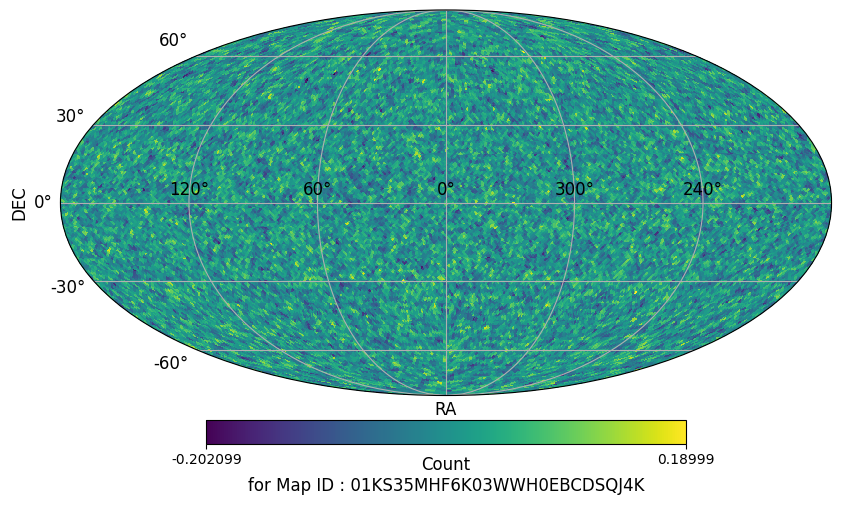

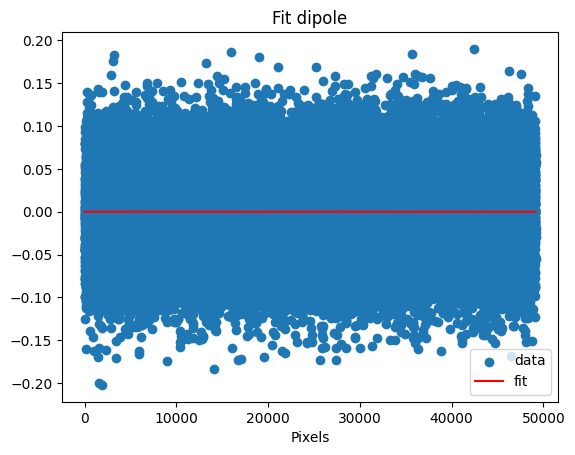

In [3]:
DIR = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
clFile = DIR + sufix + '.fits'

clMapper = CountMapper.from_map_fits(clFile, idx=0, nest=False) #first clustering map
clMapper = clMapper.invert_nest()

generator = Generator(nside = clMapper.nside, nest = clMapper.nest)

init =  (0, 100, 0)
clMapper.fit_dipole("", init, fit_monop=False)

## Dipole creation

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.456e-07 (χ²/ndof = 0.0)  │              Nfcn = 262              │
│ EDM = 3.46e-07 (Goal: 0.0002)    │            time = 2.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.100   │   0.002   │   -0.002   │   0.002    │    0    │    1    │       │
│ 1 │ ra   │  168.00   │   0.23    │   -0.23    │    0.23    │    0    │   360   │       │
│ 2 │ dec  │   -7.0    │    0.4    │    -0.4    │    0.4     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.002   │   0.002   │   -0.23   │   0.23    │   -0.4    │    0.4    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 4.07e-06    -0e-6     0e-6 │
│  ra │    -0e-6   0.0509    -0.03 │
│ dec │     0e-6    -0.03    0.134 │
└─────┴────────────────────────────┘

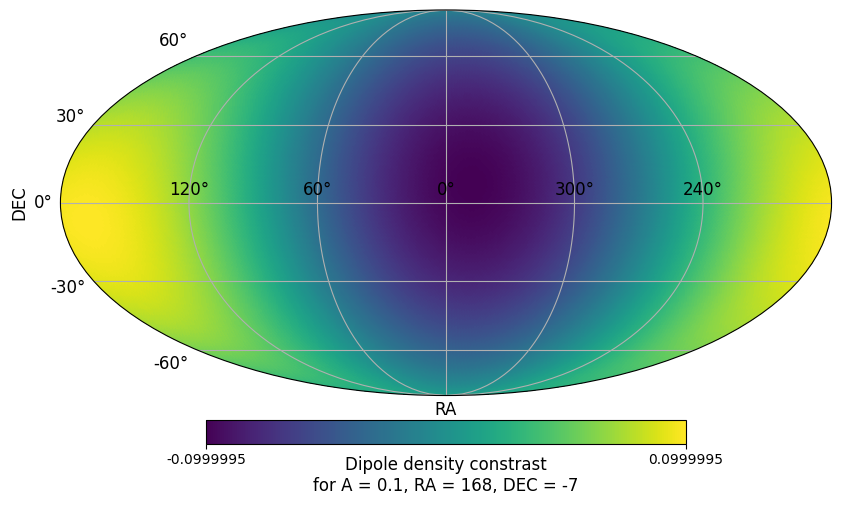

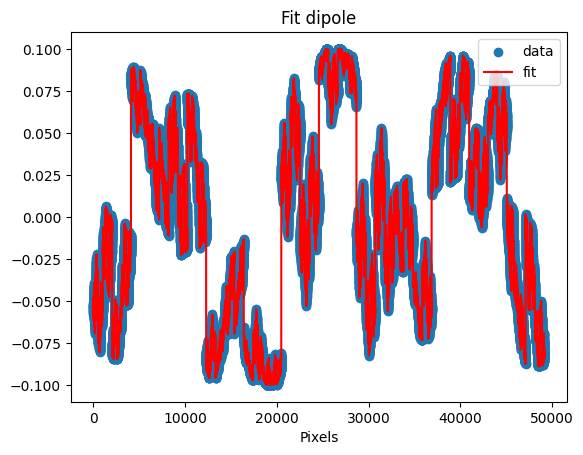

In [7]:
A, ra, dec = 0.1, 168, -7
dipoleMapper = generator.generate_dipoleContrast(A, ra, dec)

init =  (1, 100, 0)
dipoleMapper.fit_dipole("", init, fit_monop=False)

## Dipole + clustering

### Model comparison

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2732 (χ²/ndof = 0.1)       │              Nfcn = 239              │
│ EDM = 1.92e-07 (Goal: 0.0002)    │            time = 2.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  14.8e-3  │  0.9e-3   │  -0.9e-3   │   0.9e-3   │    0    │    1    │       │
│ 1 │ ra   │   174.1   │    2.5    │    -2.5    │    2.5     │    0    │   360   │       │
│ 2 │ dec  │   -5.7    │    2.5    │    -2.5    │    2.5     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.9e-3  │  0.9e-3   │   -2.5    │    2.5    │   -2.5    │    2.5    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 7.72e-07 176.2e-6  32.1e-6 │
│  ra │ 176.2e-6     6.36        0 │
│ dec │  32.1e-6        0     6.34 │
└─────┴────────────────────────────┘

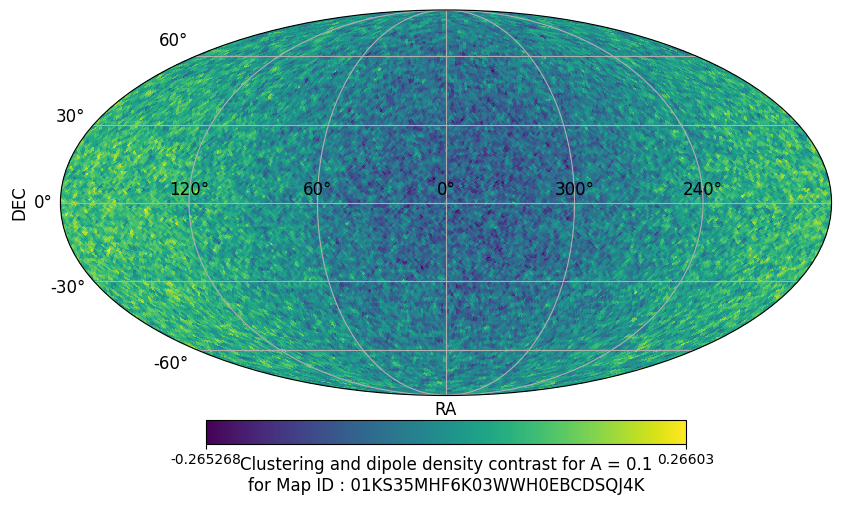

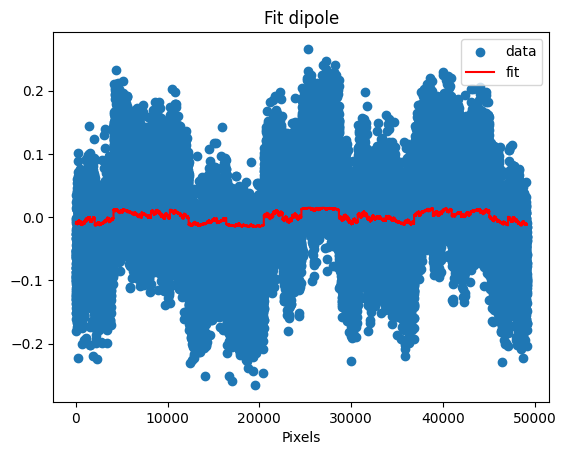

In [5]:
dipoleClMapper = generator.generate_dipoleContrast(A, ra, dec, clMapper=clMapper, unit = f"Clustering and dipole density contrast for A = {A}")
init =  (1, 100, 0)
dipoleClMapper.fit_dipole("", init, fit_monop=False)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 280.7 (χ²/ndof = 0.0)      │              Nfcn = 355              │
│ EDM = 2.2e-09 (Goal: 0.0002)     │            time = 3.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   1.00    │   0.01    │            │            │    0    │         │  yes  │
│ 1 │ A    │  1.3e-12  │568204061.6e-12│  -1.2e-12  │568204061.6e-12│    0    │    1    │       │
│ 2 │ ra   │  0.33e3   │  0.33e3   │  -0.33e3   │   0.33e3   │    0    │   360   │       │
│ 3 │ dec  │    -50    │    90     │    -90     │     90     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -1.2e-12  │568204061.6e-12│  -0.33e3  │  0.33e3   │    -90    │    90     │
│  Valid   │   True    │   False   │   False   │   False   │   False   │   False   │
│ At Limit │   True    │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   True    │   True    │   True    │   True    │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────┐
│     │             N*              A             ra            dec │
├─────┼─────────────────────────────────────────────────────────────┤
│  N* │              0              0              0              0 │
│   A │              0       2.84e-15  -8.7643779e-9 -20.0433585e-9 │
│  ra │              0  -8.7643779e-9       4.44e+04              0 │
│ dec │              0 -20.0433585e-9              0       2.31e+04 │
└─────┴─────────────────────────────────────────────────────────────┘

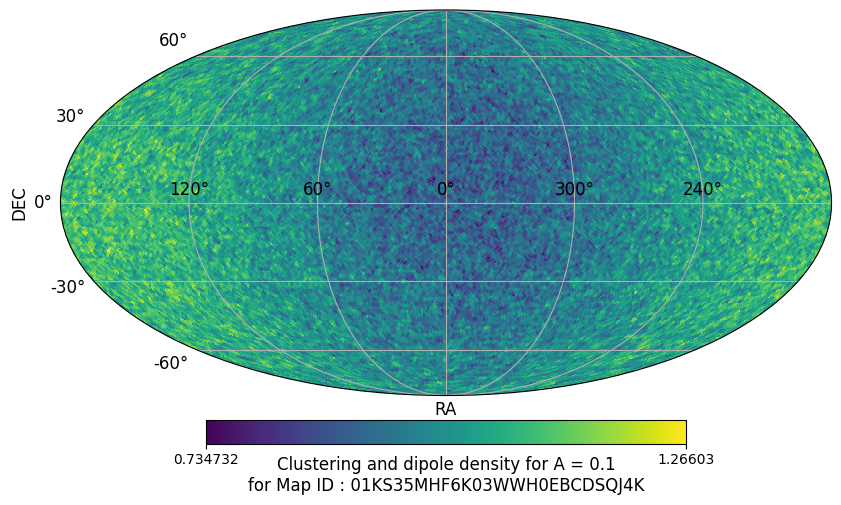

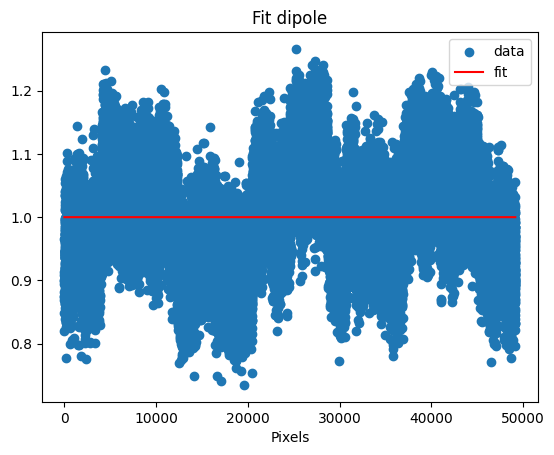

In [6]:
dipoleClMapper_dens = generator.generate_monopole(1, contrastMapper=dipoleClMapper, unit = f"Clustering and dipole density for A = {A}")

init =  (1, 1, 100, 0)
dipoleClMapper_dens.fit_dipole("", init, fit_monop=True, fixed='N*')

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 111.9 (χ²/ndof = 0.0)      │              Nfcn = 416              │
│ EDM = 5.01e-07 (Goal: 0.0002)    │            time = 4.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   0.998   │   0.005   │   -0.005   │   0.005    │    0    │         │       │
│ 1 │ A    │   0.101   │   0.008   │   -0.008   │   0.008    │    0    │    1    │       │
│ 2 │ ra   │    168    │     4     │     -4     │     4      │    0    │   360   │       │
│ 3 │ dec  │    -7     │     4     │     -4     │     4      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.005   │   0.005   │  -0.008   │   0.008   │    -4     │     4     │    -4     │     4     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │ 2.03e-05       -0       -0        0 │
│   A │       -0 6.08e-05 -0.01e-3 -0.01e-3 │
│  ra │       -0 -0.01e-3     19.9        0 │
│ dec │        0 -0.01e-3        0     19.7 │
└─────┴─────────────────────────────────────┘

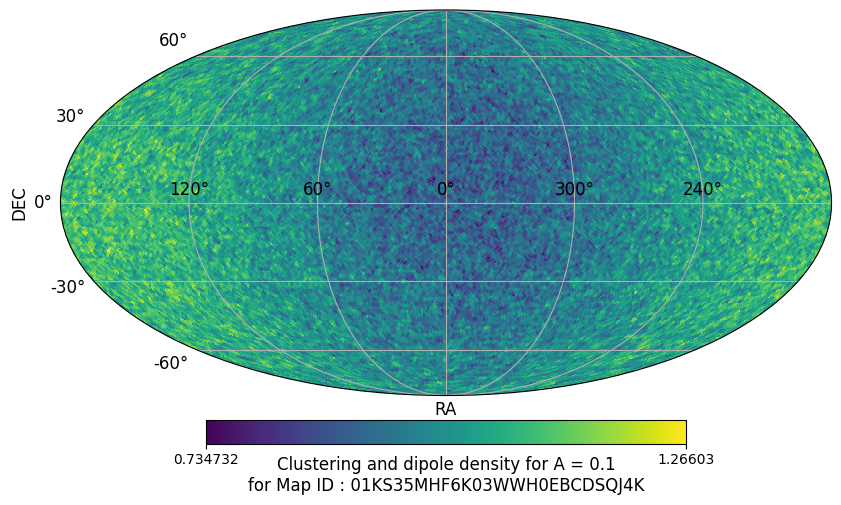

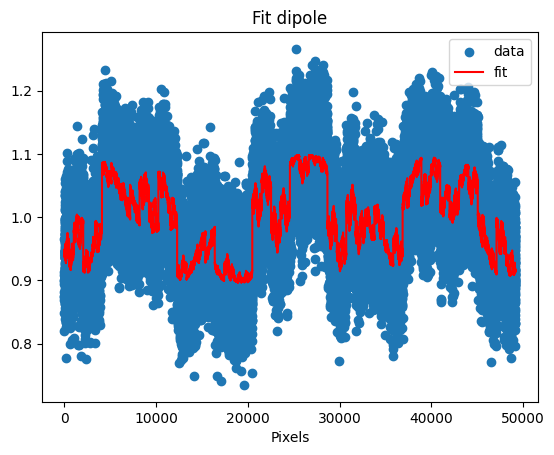

In [7]:
init =  (0, 1, 100, 0)
dipoleClMapper_dens.fit_dipole("", init, fit_monop=True)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.119e+08 (χ²/ndof = 2277.4)│              Nfcn = 275              │
│ EDM = 9.78e-06 (Goal: 0.0002)    │            time = 2.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.564e3 │  0.005e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A    │100.969e-3 │ 0.008e-3  │ -0.008e-3  │  0.008e-3  │    0    │    1    │       │
│ 2 │ ra   │  168.179  │   0.004   │   -0.004   │   0.004    │    0    │   360   │       │
│ 3 │ dec  │  -6.705   │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │   -8e-6   │   8e-6    │  -0.004   │   0.004   │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │     20.3  0.82e-9       -0       -0 │
│   A │  0.82e-9 6.08e-11 -0.02e-9 -0.02e-9 │
│  ra │       -0 -0.02e-9 1.99e-05        0 │
│ dec │       -0 -0.02e-9        0 1.97e-05 │
└─────┴─────────────────────────────────────┘

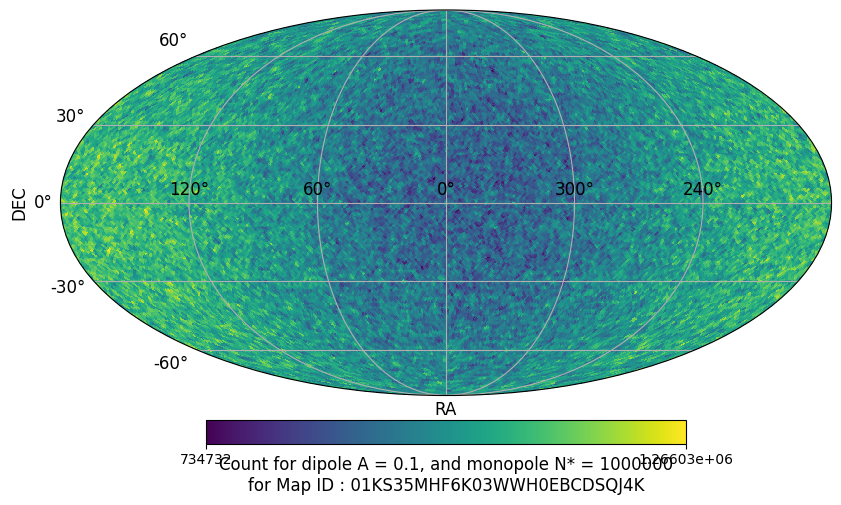

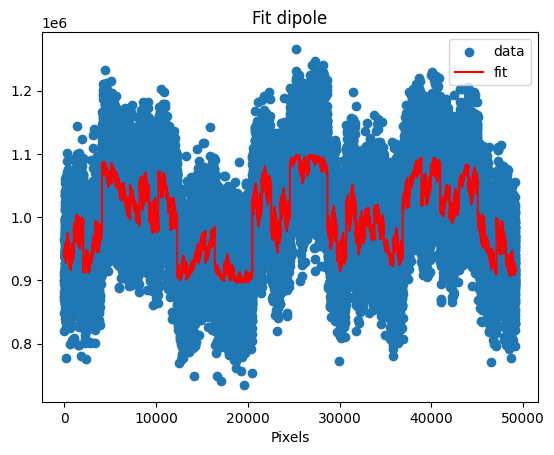

In [8]:
monopMapper = generator.generate_monopole(NSource_px_th, contrastMapper=dipoleClMapper, unit = f"Count for dipole A = {A}, and monopole N* = {NSource_px_th}")

init =  (1e6, 1, 100, 0)
monopMapper.fit_dipole("", init)

### Study of $A$

In [7]:
def get_clDipMonop(A, ra=ra, dec=dec, M=NSource_px_th, poissNoise=False, densField=False):
    dipoleClMapper = generator.generate_dipoleContrast(A, ra, dec, clMapper=clMapper, unit = f"Clustering and dipole density contrast for A = {A}")
    monopMapper = generator.generate_monopole(M, contrastMapper=dipoleClMapper, unit = f"Count for dipole A = {A}, and monopole N* = {M}")
    
    if poissNoise: monopMapper = monopMapper.get_poisson_noise()
    if densField: monopMapper = monopMapper.get_densField()
    monopMapper._set_suffixTextPlot(unit = f"dipole A = {A}, and monopole N* = {NSource_px_th}")

    return monopMapper, dipoleClMapper


def get_add_param(m, A, ra=ra, dec=dec, M=NSource_px_th):
    add_param = {}
    for k, v in zip(m.values.to_dict().keys(), (M, A, ra, dec)): add_param[k + "_true"] = v
    return add_param


def get_compute(A, ra=ra, dec=dec, M=NSource_px_th, init=(1e6, 1, 100, 0), fixed=[], poissNoise=False, densField=False):
    if densField and ("N*" not in fixed): fixed.append("N*")
    monopMapper, dipoleClMapper = get_clDipMonop(A, ra, dec, M, poissNoise, densField=densField)
    m = monopMapper.fit_dipole("", init, plot_fig=False, plot_map=False, verbose=False, fixed=fixed)
    add_param = get_add_param(m, A, ra, dec, M)
    if poissNoise: add_param["Cluster_ID"] = dipoleClMapper.ID
    mapID = monopMapper.ID
    dic_param = get_dicParam_minuit(m, mapID, add_param=add_param)
    return m, dic_param, monopMapper



densField = False
poissNoise = True
Alist = np.logspace(-3, -1, 50)
Atest = Alist[0]

M, init = NSource_px_th, (1, 1, 100, 0)
fixed = []

dfMinuit, mapList, IDlist, mapperList = [], [], [], []

for i in range(len(Alist)):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    Atest = Alist[i]
    m, dic_param, monopMapper = get_compute(Atest, M=M, init=init, fixed=fixed, poissNoise=poissNoise, densField=densField)
    dfMinuit.append(dic_param)
    mapList.append(monopMapper._select_useMap(""))
    IDlist.append(str(monopMapper.ID))
    mapperList.append(monopMapper)
print('\nFit complete.')

dfMinuit = pd.concat(dfMinuit, ignore_index=True)
dicMaps = get_dicMaps(IDlist, mapList)
dfMinuit

#### Saving data

In [16]:
output_path = "Fit_Clusters/Clusters_Dipole/Clusters_Dipole_"
if poissNoise: suffix_poiss = "_poissVar"
else: suffix_poiss = ""
if densField: suffix = "Param_study_NoMonop"
else: suffix = "Param_study_Monop"
outputfile = output_path + suffix + suffix_poiss +".fits"


HDU_target='A_STUDY'

header_global = {'MAP_TYPE': 'Clustering', 'INJECT_DIPOLE': True, 'INJECT_MONOPOLE': not densField, 'POISSON_NOISE' : poissNoise}
if poissNoise: dicMaps_fiterd = get_save_dicMaps(dicMaps, outputfile, HDU_target=f'{HDU_target}_MAPS', header_global=header_global)
dfMinuit_filtered = get_save_fit_dfMinuit(dfMinuit, outputfile, HDU_target=HDU_target, header_global=header_global)

File Fit_Clusters/Clusters_Dipole/Clusters_Dipole_Param_study_Monop_poissVar.fits doesn't exist ; creating one.
Coulndn't find HDU A_STUDY_MAPS in the data ; creating one.
Saving maps in Fit_Clusters/Clusters_Dipole/Clusters_Dipole_Param_study_Monop_poissVar.fits
Saving complete.
Coulndn't find HDU A_STUDY in the data ; creating one.
Saving Dataframe results in Fit_Clusters/Clusters_Dipole/Clusters_Dipole_Param_study_Monop_poissVar.fits
Saving complete.


/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/fitMap.py:273: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(False, inplace=True)


## Density field (N* = 1)

In [14]:
DIR = "Fit_Clusters/Clusters_Dipole/Clusters_Dipole_"
suffix = "Param_study_Monop_poissVar"
outputfile = DIR + suffix +".fits"
data4 = fitsio.FITS(outputfile)

dfMinuit = Table(data4['A_STUDY'].read())
dfMinuit = dfMinuit.to_pandas()
dfMinuit

,Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,...,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true,Cluster_ID
0,01KT3QFZZHN10T2CCQSN6K7FTS,997569.043598,1.0,4.505061,False,0.0,inf,0.001592,1.0,0.000008,...,0.281629,False,-90.0,90.0,True,1000000,0.001000,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
1,01KT3QG7763SY4ZMZTHATS8R62,997571.493397,1.0,4.505067,False,0.0,inf,0.001690,1.0,0.000008,...,0.265327,False,-90.0,90.0,True,1000000,0.001099,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
2,01KT3QGBKCXCCVBVAX36NNF686,997566.169523,1.0,4.505056,False,0.0,inf,0.001774,1.0,0.000008,...,0.252677,False,-90.0,90.0,True,1000000,0.001207,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
3,01KT3QGHRQQ5ZW5VEPVZCFG2PB,997566.885894,1.0,4.505057,False,0.0,inf,0.001889,1.0,0.000008,...,0.237349,False,-90.0,90.0,True,1000000,0.001326,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
4,01KT3QGQ0PT12SAX3GJ4S79HX6,997571.002530,1.0,4.505067,False,0.0,inf,0.002035,1.0,0.000008,...,0.220335,False,-90.0,90.0,True,1000000,0.001456,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
5,01KT3QGXGGEK66KP2ZMDPYXEY8,997573.888580,1.0,4.505072,False,0.0,inf,0.002162,1.0,0.000008,...,0.207406,False,-90.0,90.0,True,1000000,0.001600,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
6,01KT3QH1WMDJEKT52R139KRZEH,997580.265290,1.0,4.505088,False,0.0,inf,0.002317,1.0,0.000008,...,0.193492,False,-90.0,90.0,True,1000000,0.001758,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
7,01KT3QH6JGJMDVCB2S71H6F7FB,997557.283915,1.0,4.505039,False,0.0,inf,0.002490,1.0,0.000008,...,0.180010,False,-90.0,90.0,True,1000000,0.001931,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
8,01KT3QHBV0MJZE115V08RM5P1H,997571.947638,1.0,4.505072,False,0.0,inf,0.002672,1.0,0.000008,...,0.167774,False,-90.0,90.0,True,1000000,0.002121,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
9,01KT3QHG3511N95GSK4CGP0NAH,997571.005839,1.0,4.505067,False,0.0,inf,0.002892,1.0,0.000008,...,0.155026,False,-90.0,90.0,True,1000000,0.002330,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K


In [11]:
def get_data_densField_df(fits, idx, HDU="A_STUDY"):
    df = Table(fits[HDU].read())
    init = [df[name + "_init"][idx] for name in ("N*", "A", "ra", "dec")]
    init[0] = 1 #because density field.
    true_vals = [df[name + "_true"][idx] for name in ("A", "ra", "dec", "N*")]
    true_vals[-1] = 1
    clID = df['Cluster_ID'][idx]
    mapID, hpmap = fits[HDU +"_MAPS"][idx]
    monopMapper = CountMapper.from_map(hpmap)
    monopMapper.set_mapID(mapID)
    return monopMapper, init, true_vals, clID


def get_add_param(m, A, ra=ra, dec=dec, M=NSource_px_th):
    add_param = {}
    for k, v in zip(m.values.to_dict().keys(), (M, A, ra, dec)): add_param[k + "_true"] = v
    return add_param


def get_compute_densField_df(fits, idx, HDU="A_STUDY", fixed=["N*"], poissNoise=False):
    monopMapper, init, true_vals, clID = get_data_densField_df(fits, idx, HDU)
    densMapper = monopMapper.get_densField()
    m = densMapper.fit_dipole("", init, plot_fig=False, plot_map=False, verbose=False, fixed=fixed)
    add_param = get_add_param(m, *true_vals)
    if poissNoise: add_param["Cluster_ID"] = clID
    mapID = densMapper.ID
    dic_param = get_dicParam_minuit(m, mapID, add_param=add_param)
    return m, dic_param, densMapper



poissNoise = True
dfMinuitDens, mapListDens, IDlistDens = [], [], []

for i in range(len(dfMinuit)):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    m, dic_param, densMapper = get_compute_densField_df(data4, i, poissNoise=poissNoise, fixed=[])
    dfMinuitDens.append(dic_param)
    mapListDens.append(densMapper._select_useMap(""))
    IDlistDens.append(str(densMapper.ID))
print('\nFit complete.')

dfMinuitDens = pd.concat(dfMinuitDens, ignore_index=True)
dicMapsDens = get_dicMaps(IDlistDens, mapListDens)
dfMinuitDens

i = 0	i = 10	i = 20	i = 30	i = 40	
Fit complete.


,Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,...,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true,Cluster_ID
0,01KT3QFZZHN10T2CCQSN6K7FTS,0.997744,1.0,0.004505,False,0.0,inf,2.881285e-04,1.0,0.045266,...,162.119480,False,-90.0,90.0,True,1,0.001000,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
1,01KT3QG7763SY4ZMZTHATS8R62,0.997743,1.0,0.004505,False,0.0,inf,2.215300e-04,1.0,0.055189,...,164.112807,False,-90.0,90.0,True,1,0.001099,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
2,01KT3QGBKCXCCVBVAX36NNF686,0.997741,1.0,0.004505,False,0.0,inf,3.258127e-04,1.0,0.040056,...,144.802383,False,-90.0,90.0,True,1,0.001207,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
3,01KT3QGHRQQ5ZW5VEPVZCFG2PB,0.997707,1.0,0.004505,False,0.0,inf,7.166340e-06,1.0,0.210973,...,128.201546,False,-90.0,90.0,True,1,0.001326,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
4,01KT3QGQ0PT12SAX3GJ4S79HX6,0.997741,1.0,0.004505,False,0.0,inf,2.075821e-06,1.0,0.026757,...,91.653190,False,-90.0,90.0,True,1,0.001456,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
5,01KT3QGXGGEK66KP2ZMDPYXEY8,0.997741,1.0,0.004505,False,0.0,inf,6.003688e-07,1.0,0.022219,...,93.035369,False,-90.0,90.0,True,1,0.001600,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
6,01KT3QH1WMDJEKT52R139KRZEH,0.997744,1.0,0.004505,False,0.0,inf,2.876714e-06,1.0,0.030341,...,102.576693,False,-90.0,90.0,True,1,0.001758,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
7,01KT3QH6JGJMDVCB2S71H6F7FB,0.997726,1.0,0.004505,False,0.0,inf,4.807873e-07,1.0,0.055180,...,118.521287,False,-90.0,90.0,True,1,0.001931,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
8,01KT3QHBV0MJZE115V08RM5P1H,0.997742,1.0,0.004505,False,0.0,inf,2.656873e-04,1.0,0.045365,...,151.928229,False,-90.0,90.0,True,1,0.002121,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
9,01KT3QHG3511N95GSK4CGP0NAH,0.997712,1.0,0.004505,False,0.0,inf,4.401864e-06,1.0,0.626951,...,163.608524,False,-90.0,90.0,True,1,0.002330,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K


In [13]:
HDU_target='A_STUDY'
header_global = {'MAP_TYPE': 'Clustering', 'INJECT_DIPOLE': True, 'INJECT_MONOPOLE': True, 'POISSON_NOISE' : poissNoise}
data4.close()

dfMinuit_filtered_Dens = get_save_fit_dfMinuit(dfMinuitDens, outputfile, HDU_target=f"{HDU_target}_densField", header_global=header_global)

Saving Dataframe results in Fit_Clusters/Clusters_Dipole/Clusters_Dipole_Param_study_Monop_poissVar.fits
Saving complete.


/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/fitMap.py:274: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(False, inplace=True)
